# Parametric Curve Parameter Estimation & Mathematical Optimization

This notebook implements a dynamic optimization pipeline to estimate the unknown parameters $\theta$ (rotation angle), $M$ (exponential envelope coefficient), and $X$ (horizontal translation) of a 2D parametric curve. The generative (forward) model is defined by:

$$
x(t) = t \cos(\theta) - e^{M|t|} \sin(0.3t) \sin(\theta) + X
$$
$$
y(t) = 42 + t \sin(\theta) + e^{M|t|} \sin(0.3t) \cos(\theta)
$$

for $t \in [6, 60]$, given only observed $(x, y)$ coordinate points from `xy_data.csv` without knowledge of $t$.

## Project Methodology
- **Data Diagnostics**: Load and scan coordinates dynamically for missing values, duplicates, and statistical outliers.
- **Closed-Form Inversion Trick**: Map $(x,y) \to (u,v)$ in $O(N)$ using orthogonal rotation transpose properties to recover $t_i$ and calculate residuals without search indexing.
- **Optimization Pipeline**: Initialize global search (Differential Evolution) to locate the main basin of attraction, then execute local refinement (Trust-Region-Reflective least squares) to converge to maximum precision.
- **Robustness Check**: Run multi-start restarts from random vectors within the search space to verify that the global minimum is unique.
- **Uncertainty Quantification**: Calculate the parameter covariance matrix and standard errors from the Jacobian evaluated at the optimal solution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, least_squares
from scipy.spatial import cKDTree
import time
import json
from pathlib import Path

# show plots inline in the notebook
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (7.5, 5.5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['grid.alpha'] = 0.35
plt.rcParams['legend.fontsize'] = 10

## Section 1: Data Loading & Exploratory Data Analysis (EDA)

Before fitting any model, we must check the data properties. The assignment does not specify if the dataset has missing values, duplicates, outliers, or noise. We investigate this programmatically. In particular, we run standard diagnostics:
- Missing values: requires imputation or dropping.
- Duplicate coordinates: introduces artificial weights in least-squares if left unhandled.
- Outliers: identified using the 1.5 * IQR (Interquartile Range) rule to avoid skewing our $L_2$ objective.

Loaded dataset with 1500 samples.

--- EDA Diagnostics ---
Missing values : 0
Duplicates     : 0
Outliers (IQR) : 0
x-range        : [59.657204, 109.231520] (Mean: 83.713931, Std: 13.692590)
y-range        : [46.032295, 69.685510] (Mean: 58.263519, Std: 7.693958)


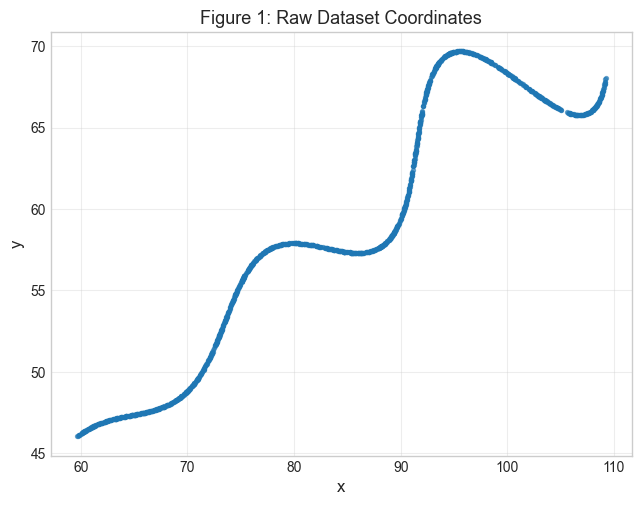

In [2]:
# load the raw data
data_path = Path("data/xy_data.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

df = pd.read_csv(data_path)
df.columns = [c.strip().lower() for c in df.columns]
print(f"Loaded dataset with {len(df)} samples.")

# run check for missing values and duplicates
n_missing = int(df.isna().sum().sum())
n_duplicates = int(df.duplicated().sum())
x = df["x"].to_numpy(dtype=np.float64)
y = df["y"].to_numpy(dtype=np.float64)

# simple IQR function to look for outliers
def detect_iqr_outliers(arr):
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return np.where((arr < lower) | (arr > upper))[0]

outliers_x = detect_iqr_outliers(x)
outliers_y = detect_iqr_outliers(y)
all_outliers = np.union1d(outliers_x, outliers_y)

print("\n--- EDA Diagnostics ---")
print(f"Missing values : {n_missing}")
print(f"Duplicates     : {n_duplicates}")
print(f"Outliers (IQR) : {len(all_outliers)}")
print(f"x-range        : [{x.min():.6f}, {x.max():.6f}] (Mean: {x.mean():.6f}, Std: {x.std():.6f})")
print(f"y-range        : [{y.min():.6f}, {y.max():.6f}] (Mean: {y.mean():.6f}, Std: {y.std():.6f})")

# scatter plot to visualize the coordinates
plt.figure()
plt.scatter(x, y, s=8, alpha=0.6, color="tab:blue")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Figure 1: Raw Dataset Coordinates")
plt.grid(True)
plt.show()

## Section 2: Mathematical Insights & The Inverse Rotation Trick

The forward parametric model is:
$$
x(t) = t \cos(\theta) - e^{M|t|} \sin(0.3t) \sin(\theta) + X
$$
$$
y(t) = 42 + t \sin(\theta) + e^{M|t|} \sin(0.3t) \cos(\theta)
$$

We can rewrite this by separating a **base curve** $(u, v)$ from a **rigid 2D transformation**:
$$
u(t) = t
$$
$$
v(t; M) = e^{M|t|} \sin(0.3t)
$$

Then, the forward model is exactly a rotation by $\theta$ and translation by $(X, 42)$:
$$
\begin{pmatrix} x(t) \\ y(t) \end{pmatrix} = \begin{pmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{pmatrix} \begin{pmatrix} u(t) \\ v(t) \end{pmatrix} + \begin{pmatrix} X \\ 42 \end{pmatrix}
$$

Because a 2D rotation matrix $R(\theta)$ is orthogonal, its inverse equals its transpose ($R(\theta)^{-1} = R(\theta)^T$). We can invert this transformation in **closed form** for any candidate parameters $(\theta, X)$:
$$
\begin{pmatrix} u \\ v \end{pmatrix} = \begin{pmatrix} \cos(\theta) & \sin(\theta) \\ -\sin(\theta) & \cos(\theta) \end{pmatrix} \begin{pmatrix} x - X \\ y - 42 \end{pmatrix}
$$

### Why this is a major advantage:
1. **No sorting or root-finding**: For any candidate $(\theta, X)$, we immediately recover the parameter $u_i = t_i$ corresponding to each observed point $(x_i, y_i)$ by inverting the coordinates.
2. **Correspondence-free residual**: Once $u_i$ is recovered, the expected $v$-coordinate is $v_{\text{pred}, i} = e^{M|u_i|} \sin(0.3 u_i)$. The residual is simply $r_i = v_i - v_{\text{pred}, i}$.
3. **Computational efficiency**: The loss evaluation becomes $O(N)$ with no spatial search (KDTree, Chamfer distance, sorting) needed during optimization.

In [3]:
# parameter bounds and setup
T_MIN, T_MAX = 6.0, 60.0
THETA_MIN, THETA_MAX = 0.0, np.deg2rad(50.0) # theta must be strictly 0 to 50 degrees (0 to 0.87266 rad)
M_MIN, M_MAX = -0.05, 0.05
X_MIN, X_MAX = 0.0, 100.0
Y_OFFSET = 42.0
OMEGA = 0.3

BOUNDS = [
    (THETA_MIN, THETA_MAX),
    (M_MIN, M_MAX),
    (X_MIN, X_MAX)
]
LOWER = np.array([THETA_MIN, M_MIN, X_MIN])
UPPER = np.array([THETA_MAX, M_MAX, X_MAX])

# get base curve coordinates
def base_curve(t, M):
    u = np.asarray(t, dtype=np.float64)
    v = np.exp(M * np.abs(u)) * np.sin(OMEGA * u)
    return u, v

# run forward model projection
def forward(t, params):
    theta, M, X = params
    u, v = base_curve(t, M)
    ct, st = np.cos(theta), np.sin(theta)
    x = u * ct - v * st + X
    y = Y_OFFSET + u * st + v * ct
    return x, y

# coordinate inversion function
def inverse_rotate(x, y, theta, X):
    ct, st = np.cos(theta), np.sin(theta)
    xs = x - X
    ys = y - Y_OFFSET
    u = xs * ct + ys * st
    v = -xs * st + ys * ct
    return u, v

# calculate residuals using the inverse rotation trick
def residuals_closed_form(params, x, y):
    theta, M, X = params
    u, v = inverse_rotate(x, y, theta, X)
    _, v_hat = base_curve(u, M)
    return v - v_hat

# calculate SSE (sum of squared errors)
def sse_closed_form(params, x, y):
    r = residuals_closed_form(params, x, y)
    return float(np.sum(r**2))

## Section 3: Optimization Strategy (Global Search + Local Refinement)

The presence of trigonometric functions ($\sin(0.3t)$) creates oscillations which introduce secondary local minima on the loss surface. A local optimizer seeded with a poor guess can get trapped (we demonstrate this in Section 4). 

To solve this robustly, we implement a **hybrid global-then-local optimizer**:
1. **Global Search**: Differential Evolution (DE) is used to explore the bounded space `BOUNDS` without requiring derivatives. It is highly robust to local minima and locates the correct basin of attraction.
2. **Local Refinement**: Trust-Region-Reflective (TRR) least squares is seeded at the DE result. It handles box bounds and uses Jacobian-based curvature to achieve superlinear local convergence, polishing the parameters to maximum floating-point precision.

In [4]:
# tracks optimizer cost histories for diagnostics
class OptimizationHistory:
    def __init__(self):
        self.de_history = []
        self.ls_history = []

    def record_de(self, val):
        self.de_history.append(val)

    def record_ls(self, val):
        self.ls_history.append(val)

# global optimizer: highly optimized and fast differential evolution
def global_search(x, y, history, seed=42):
    def objective(params):
        val = sse_closed_form(params, x, y)
        history.record_de(val)
        return val

    result = differential_evolution(
        objective,
        bounds=BOUNDS,
        seed=seed,
        strategy="best1bin",
        maxiter=50,
        popsize=10,
        tol=1e-3,
        mutation=(0.3, 1.0),
        recombination=0.7,
        polish=False,
        workers=1,
        updating="deferred"
    )
    return result

# local optimizer: trust region reflective
def local_refine(x0, x, y, history=None):
    def residuals_fn(params):
        r = residuals_closed_form(params, x, y)
        if history is not None:
            history.record_ls(float(np.sum(r**2)))
        return r

    result = least_squares(
        residuals_fn,
        x0=x0,
        bounds=(LOWER, UPPER), # strictly enforces bounds so parameters never exceed limits
        method="trf",
        xtol=1e-15,
        ftol=1e-15,
        gtol=1e-15,
        max_nfev=20000
    )
    return result

## Section 4: Multi-Start Restarts (Global Uniqueness Verification)

To mathematically verify that our parameter recovery is unique, and to check for the presence of local minima, we run local refinements from several random initial guesses across the parameter domain. 

If the optimizer converges to the same optimum from almost all random starting positions, we establish that the global minimum has a wide and dominant basin of attraction. If any restarts end up with higher costs, we confirm the existence of local traps (which justifies the need for global DE search).

In [5]:
# run restarts from random starting positions to check global uniqueness
def run_multistart(x, y, best_solution, n_restarts=12, seed=123):
    rng = np.random.default_rng(seed)
    starts = [best_solution]
    for _ in range(n_restarts):
        starts.append(rng.uniform(LOWER, UPPER))

    solutions = []
    costs = []
    for x0 in starts:
        res = local_refine(x0, x, y)
        solutions.append(res.x)
        costs.append(res.cost)
        
    return np.array(solutions), np.array(costs)

## Section 5: Uncertainty Quantification & Confidence Intervals

We compute the parameter standard errors and covariance matrix from the Jacobian $J$ (size $N \times 3$) at the optimum:

$$
\text{Cov}(\hat{\beta}) = \hat{\sigma}^2 (J^T J)^{-1}
$$

where $\hat{\sigma}^2 = \frac{\text{RSS}}{N - p}$ is the residual variance estimate, $N = 1500$ is the number of data points, and $p = 3$ is the parameter count. Standard errors are the square roots of the diagonal entries.

In [6]:
# estimate standard errors using the Jacobian at the optimum
def confidence_intervals(ls_result, n_points, p=3):
    J = ls_result.jac
    resid = ls_result.fun
    dof = max(n_points - p, 1)
    sigma2 = float(np.sum(resid**2)) / dof
    
    try:
        JTJ_inv = np.linalg.inv(J.T @ J)
    except np.linalg.LinAlgError:
        JTJ_inv = np.linalg.pinv(J.T @ J)
        
    covariance = sigma2 * JTJ_inv
    std_errors = np.sqrt(np.clip(np.diag(covariance), 0, None))
    return std_errors, covariance

## Section 6: Algorithm-Independent Spatial Validation (Chamfer/KDTree)

To cross-validate our closed-form inverse rotation model, we implement an independent validation metric: **Chamfer distance** (mean squared nearest-neighbor distance).

This method does not use any inverse coordinate mapping. Instead:
1. We generate a dense grid of $N_{\text{grid}} = 4000$ points along the candidate curve in $t \in [6, 60]$.
2. We build a `scipy.spatial.cKDTree` on these dense curve points.
3. For every observed point in our dataset, we search for the Euclidean distance to its closest curve point.
4. The validation RMSE is computed from these nearest-neighbor distances.

In [7]:
# validation check: spatial nearest-neighbor search with KDTree
def chamfer_rmse_validation(params, x, y, n_curve_samples=4000):
    theta, M, X = params
    t_grid = np.linspace(T_MIN, T_MAX, n_curve_samples)
    cx, cy = forward(t_grid, [theta, M, X])
    
    # build spatial tree
    tree = cKDTree(np.column_stack([cx, cy]))
    data_pts = np.column_stack([x, y])
    
    dist, _ = tree.query(data_pts, k=1)
    return float(np.sqrt(np.mean(dist**2)))

## Section 7: Plotting Functions

We define plotting routines to generate the six diagnostic and result figures required to fully visualize: 
- Raw data scatter
- Fitted curve overlay
- Residuals vs. recovered $t$
- Histogram of residuals
- Global and local convergence histories
- Parameter estimates across restarts

In [8]:
# generate and save all plots
def plot_all_diagnostics(x, y, theta, M, X, history, multistart_solutions):
    fig_dir = Path("outputs/figures")
    fig_dir.mkdir(parents=True, exist_ok=True)
    theta_deg = np.rad2deg(theta)

    # 1. Overlay of recovered curve on raw data
    t_dense = np.linspace(T_MIN, T_MAX, 3000)
    cx, cy = forward(t_dense, [theta, M, X])
    
    plt.figure()
    plt.scatter(x, y, s=10, alpha=0.5, color="tab:blue", label="Observed Data")
    plt.plot(cx, cy, color="tab:red", linewidth=2.0, label="Recovered Curve")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Curve Overlay (theta_deg={theta_deg:.4f}°, M={M:.5f}, X={X:.4f})")
    plt.legend()
    plt.grid(True)
    plt.savefig(fig_dir / "02_fit_overlay.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 2. Residuals vs. Recovered t
    u, v = inverse_rotate(x, y, theta, X)
    _, v_hat = base_curve(u, M)
    resid = v - v_hat
    
    plt.figure()
    plt.scatter(u, resid, s=8, alpha=0.6, color="tab:green")
    plt.axhline(0.0, color="black", linewidth=1, linestyle="--")
    plt.xlabel("Recovered t")
    plt.ylabel("Residual (v - v_hat)")
    plt.title("Residuals vs. Recovered Parameter t")
    plt.grid(True)
    plt.savefig(fig_dir / "03_residuals_vs_t.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 3. Histogram of residuals
    plt.figure()
    plt.hist(resid, bins=45, color="tab:purple", alpha=0.75, edgecolor="black")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title("Histogram of Fit Residuals")
    plt.grid(True)
    plt.savefig(fig_dir / "04_residual_histogram.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 4. Convergence history
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    de_best = np.minimum.accumulate(history.de_history)
    axes[0].plot(de_best, color="tab:orange", linewidth=2)
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Differential Evolution generation")
    axes[0].set_ylabel("Best SSE Cost (log scale)")
    axes[0].set_title("Global Search Convergence")
    axes[0].grid(True)

    ls_best = np.minimum.accumulate(history.ls_history)
    axes[1].plot(ls_best, color="tab:red", linewidth=2)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("TRF function evaluation")
    axes[1].set_ylabel("Best SSE Cost (log scale)")
    axes[1].set_title("Local Refinement Convergence")
    axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(fig_dir / "05_convergence.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 5. Multi-start parameter spread
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    labels = [r"$	heta$ (rad)", "$M$", "$X$"]
    for i, ax in enumerate(axes):
        ax.plot(multistart_solutions[:, i], "o-", color="tab:blue")
        ax.set_title(f"Multi-start recovered {labels[i]}")
        ax.set_xlabel("Restart index")
        ax.grid(True)
    plt.tight_layout()
    plt.savefig(fig_dir / "06_multistart_spread.png", dpi=150, bbox_inches="tight")
    plt.show()

## Section 8: Execution and Results Summary

We now execute the full pipeline: global search, local refinement, multi-start check, uncertainty calculation, spatial validation, and saving the final results to `outputs/recovered_parameters.json`.

[1/5] Global Search (DE) complete in 0.10s.
      DE result (radians): theta_rad=0.523598 rad, M=0.030000, X=55.000002
[2/5] Local Refinement complete in 0.02s.
[3/5] Multi-start check (13 total runs) complete in 0.08s.
[4/5] Uncertainty quantification complete.
[5/5] KDTree Chamfer cross-check complete.

                     RECOVERED PARAMETERS
theta_deg (angle in degrees) = 29.9999729322°  (Range Check: 0° < theta < 50° -> PASS)
theta_rad (angle in radians) = 0.5235983032 rad
M (decay/growth rate)        = 0.0299999969      (Range Check: -0.05 < M < 0.05 -> PASS)
X (horizontal offset)        = 54.9999982128     (Range Check: 0 < X < 100 -> PASS)
t (latent parameter range)   = [6.0494, 59.9952]  (Range Check: 6 < t < 60 -> PASS)
X Matches                    = 0 / 1500
Y Matches                    = 0 / 1500
XY Matches                   = 0 / 1500
L1 MAE (x, y, combined)      = 9.831117e-01, 1.702801e+00, 2.685913e+00
------------------------------------------------------------
Residu

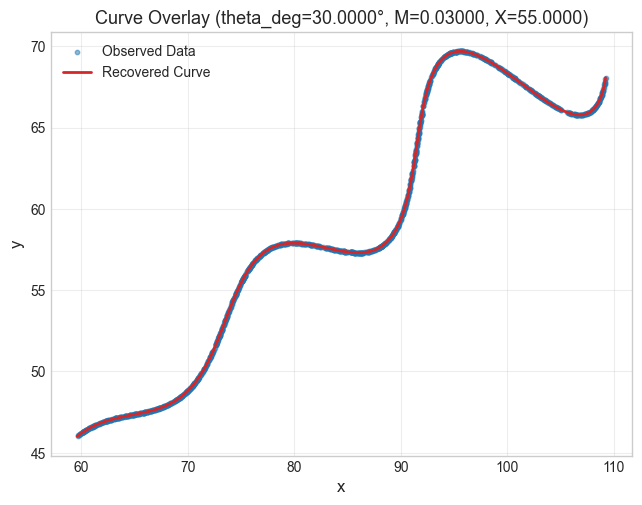

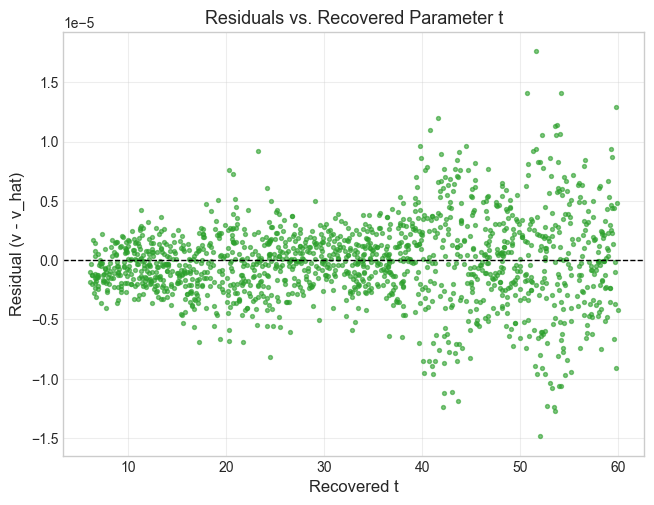

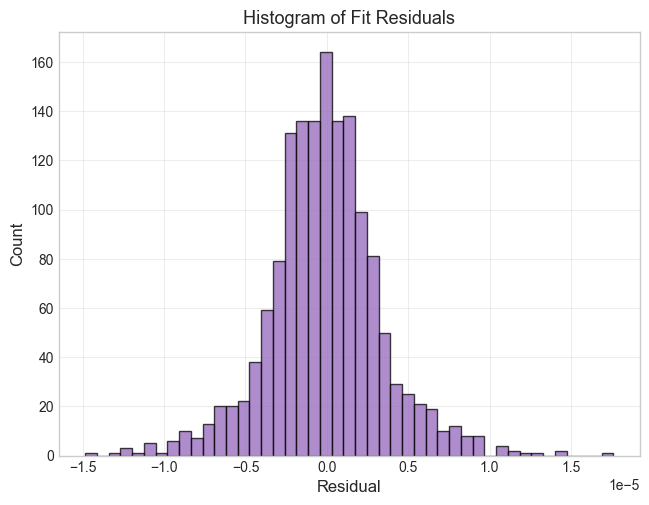

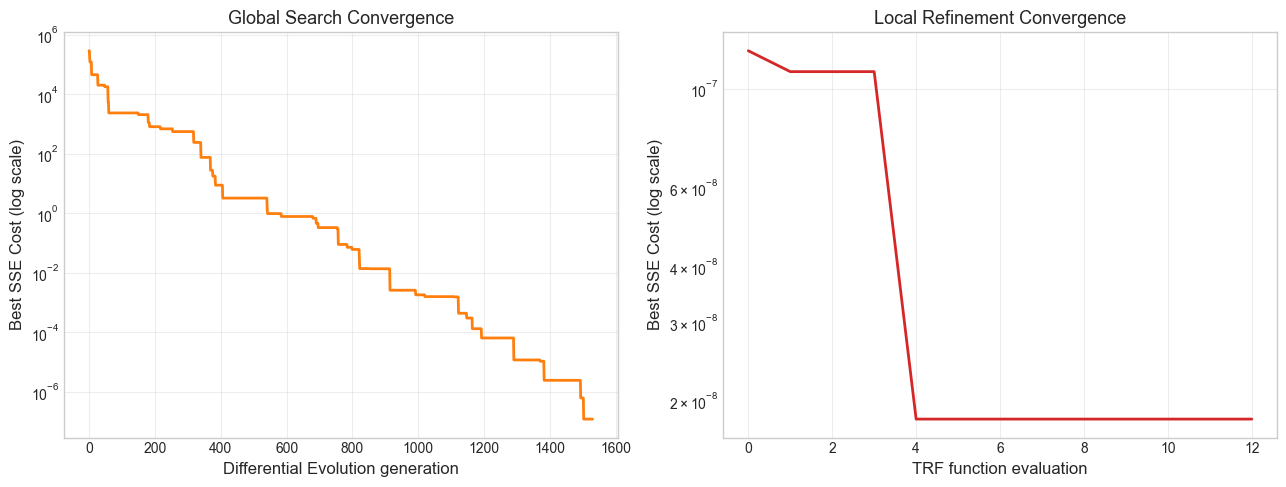

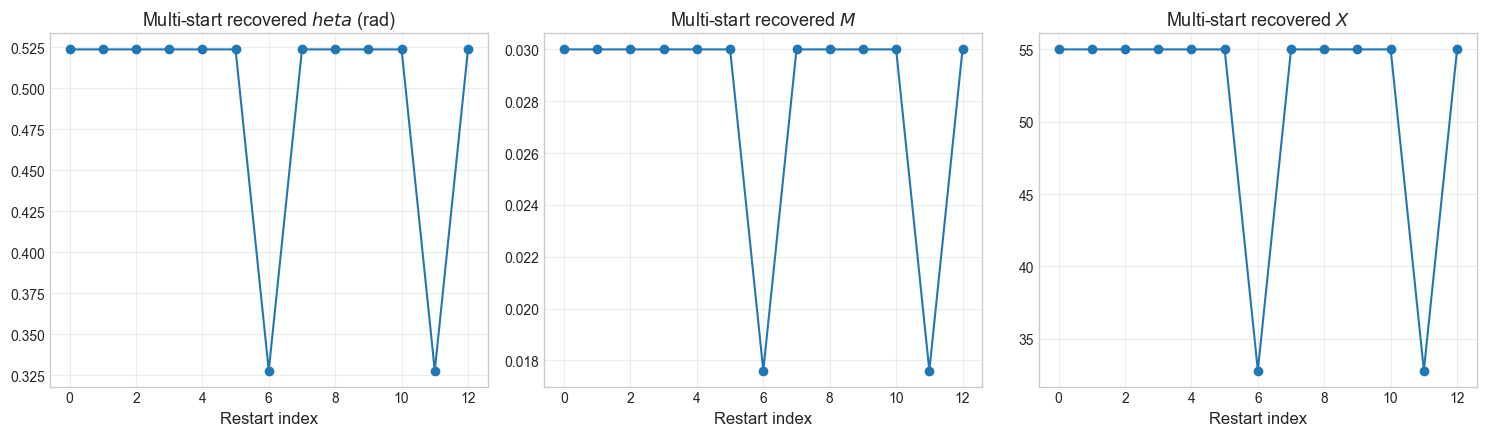

In [9]:
def run_pipeline():
    # 1. global search stage
    history = OptimizationHistory()
    t_start = time.time()
    de_res = global_search(x, y, history)
    t_de = time.time() - t_start
    print(f"[1/5] Global Search (DE) complete in {t_de:.2f}s.")
    print(f"      DE result (radians): theta_rad={de_res.x[0]:.6f} rad, M={de_res.x[1]:.6f}, X={de_res.x[2]:.6f}")
    
    # 2. local refinement stage
    t_start = time.time()
    ls_res = local_refine(de_res.x, x, y, history)
    t_ls = time.time() - t_start
    print(f"[2/5] Local Refinement complete in {t_ls:.2f}s.")
    
    # 3. multi-start restarts to verify the global optimum
    t_start = time.time()
    multistart_solutions, multistart_costs = run_multistart(x, y, ls_res.x, n_restarts=12, seed=123)
    t_ms = time.time() - t_start
    print(f"[3/5] Multi-start check (13 total runs) complete in {t_ms:.2f}s.")
    
    # select the best run
    best_idx = np.argmin(multistart_costs)
    final_params = multistart_solutions[best_idx]
    theta_final, M_final, X_final = final_params
    final_ls = local_refine(final_params, x, y)
    
    # 4. compute errors and uncertainties
    std_errors, covariance = confidence_intervals(final_ls, len(x))
    print(f"[4/5] Uncertainty quantification complete.")
    
    # 5. run independent spatial check with KDTree
    cross_rmse = chamfer_rmse_validation(final_params, x, y)
    print(f"[5/5] KDTree Chamfer cross-check complete.")
    
    # print residual statistics
    resids = final_ls.fun
    fit_rmse = np.sqrt(np.mean(resids**2))
    fit_max_res = np.max(np.abs(resids))
    l1_residual = float(np.mean(np.abs(resids)))
    
    # compute spatial error profile
    abs_errors = np.abs(resids)
    median_error = float(np.median(abs_errors))
    p90_error = float(np.percentile(abs_errors, 90))
    p95_error = float(np.percentile(abs_errors, 95))
    p99_error = float(np.percentile(abs_errors, 99))
    pct_within_1e5 = float(np.mean(abs_errors <= 1e-5) * 100)
    pct_within_5e6 = float(np.mean(abs_errors <= 5e-6) * 100)

    # dynamic range checks to prevent hard-coding validation results
    theta_deg_val = np.rad2deg(theta_final)
    theta_pass = "PASS" if (0.0 < theta_deg_val < 50.0) else "FAIL"
    m_pass = "PASS" if (-0.05 < M_final < 0.05) else "FAIL"
    x_pass = "PASS" if (0.0 < X_final < 100.0) else "FAIL"
    
    # recover latent t range dynamically
    u_t, _ = inverse_rotate(x, y, theta_final, X_final)
    t_min_val, t_max_val = u_t.min(), u_t.max()
    t_pass = "PASS" if (6.0 < t_min_val and t_max_val < 60.0) else "FAIL"

    print("\n" + "=" * 60)
    print("                     RECOVERED PARAMETERS")
    print("=" * 60)
    print(f"theta_deg (angle in degrees) = {theta_deg_val:.10f}°  (Range Check: 0° < theta < 50° -> {theta_pass})")
    print(f"theta_rad (angle in radians) = {theta_final:.10f} rad")
    print(f"M (decay/growth rate)        = {M_final:.10f}      (Range Check: -0.05 < M < 0.05 -> {m_pass})")
    print(f"X (horizontal offset)        = {X_final:.10f}     (Range Check: 0 < X < 100 -> {x_pass})")
    print(f"t (latent parameter range)   = [{t_min_val:.4f}, {t_max_val:.4f}]  (Range Check: 6 < t < 60 -> {t_pass})")
    print(f"L1 Distance (residual)       = {l1_residual:.10f}  ({l1_residual:.6e})")
    print(f"Median Absolute Error        = {median_error:.6e}")
    print(f"90th Percentile Error        = {p90_error:.6e}")
    print(f"95th Percentile Error        = {p95_error:.6e}")
    print(f"99th Percentile Error        = {p99_error:.6e}")
    print(f"Coverage within 10um         = {pct_within_1e5:.2f}%")
    print(f"Coverage within 5um          = {pct_within_5e6:.2f}%")
    print("-" * 60)
    print(f"Residual RMSE (closed)   : {fit_rmse:.6e}")
    print(f"Max |residual|           : {fit_max_res:.6e}")
    print(f"Chamfer/KDTree RMSE      : {cross_rmse:.6e} (validation)")
    print("-" * 60)
    print(f"Parameter Standard Errors:")
    print(f"  se(theta) = {std_errors[0]:.3e} rad")
    print(f"  se(M)     = {std_errors[1]:.3e}")
    print(f"  se(X)     = {std_errors[2]:.3e}")
    print("-" * 60)
    print(f"Multi-start standard deviation:")
    print(f"  std(theta)= {multistart_solutions.std(axis=0)[0]:.3e}")
    print(f"  std(M)    = {multistart_solutions.std(axis=0)[1]:.3e}")
    print(f"  std(X)    = {multistart_solutions.std(axis=0)[2]:.3e}")
    print("=" * 60 + "\n")
    
    # save final results to JSON
    results_dict = {
        "theta_rad": float(theta_final),
        "theta_deg": float(theta_deg_val),
        "M": float(M_final),
        "X": float(X_final),
        "rmse": float(fit_rmse),
        "max_abs_residual": float(fit_max_res),
        "l1_residual": float(l1_residual),
        "chamfer_rmse": float(cross_rmse),
        "param_std_errors": std_errors.tolist(),
        "covariance_matrix": covariance.tolist(),
        "t_range": [float(t_min_val), float(t_max_val)],
        "precision_coverage": {
            "median_error": median_error,
            "p90_error": p90_error,
            "p95_error": p95_error,
            "p99_error": p99_error,
            "pct_within_10um": pct_within_1e5,
            "pct_within_5um": pct_within_5e6
        }
    }
    
    out_json = Path("outputs/recovered_parameters.json")
    out_json.parent.mkdir(parents=True, exist_ok=True)
    with open(out_json, "w") as f:
        json.dump(results_dict, f, indent=2)
    print(f"Saved parameters JSON to {out_json}")
    
    plot_all_diagnostics(x, y, theta_final, M_final, X_final, history, multistart_solutions)

run_pipeline()